# Modeling


**TODO**
- **done** different models for rec, resl and rest (up to now only resl)
- **done** try bayesian optimization with xgboost/ fix hyperopt: what's the issue?
- **done** include categorical variable "veg_class"
- add models for kndvi anomaly?
- **done** check for overfitting: for each model, print training vs test R2 -> maybe have to work with gamma
- SHAP for resistance and recovery


In [1]:
import pandas as pd
import numpy as np
import json
import matplotlib.pyplot as plt

# ML
import xgboost as xgb
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.metrics import accuracy_score, confusion_matrix, mean_squared_error, r2_score
from sklearn.inspection import permutation_importance
from hyperopt import STATUS_OK, Trials, fmin, hp, tpe 
import shap

## Prepare data for model

In [2]:
# Load prepared data
df = pd.read_csv('data/output/09_29.csv')

# Rename unnamed columns (only needed with csv from 29.09.)
df = df.rename(columns={'Unnamed: 1': 'veg_class'}) #TODO: can be deleted once i have rerun analysis execution

In [5]:
df

,event_label,veg_class,n_days,t2m,t2mmin,t2mmax,prec,soil_moist,evap,evap_pot,...,9.0,10.0,11.0,12.0,13.0,14.0,15.0,16.0,18.0,19.0
0,83007,1.0,9.439828,16.274485,7.013991,25.916573,0.949040,0.160487,0.619684,0.623335,...,False,False,False,False,False,False,False,False,False,False
1,83007,5.0,17.539571,19.237293,10.049909,28.247648,1.098168,0.186558,0.794822,0.825940,...,False,False,False,False,False,False,False,False,False,False
2,83007,7.0,6.909091,25.568640,16.587254,34.162804,0.510140,0.141689,0.385934,1.074128,...,False,False,False,False,False,False,False,False,False,False
3,83007,10.0,14.817383,26.356934,16.850323,35.251453,0.580634,0.173629,0.413866,1.022274,...,False,True,False,False,False,False,False,False,False,False
4,83007,12.0,18.372679,23.235512,14.478889,31.925268,1.037939,0.234533,0.783485,0.961051,...,False,False,False,True,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
607,103567,12.0,6.000000,25.139286,22.405426,28.939657,5.551070,0.419721,2.872893,3.743174,...,False,False,False,True,False,False,False,False,False,False
608,81632,2.0,18.000000,15.296368,9.923286,21.340736,5.917609,0.445089,2.865942,2.874007,...,False,False,False,False,False,False,False,False,False,False
609,79098,7.0,12.000000,13.642197,8.687145,19.107574,0.930501,0.243993,0.451534,0.456318,...,False,False,False,False,False,False,False,False,False,False
610,121988,2.0,8.000000,20.744495,18.467050,23.423620,7.816896,0.105242,4.273697,4.762981,...,False,False,False,False,False,False,False,False,False,False


In [3]:
# One hot encoding of vegetation class
dummies = pd.get_dummies(df['veg_class'])
df = df.join(dummies) # Add to df

In [4]:
# Get number of class occurrences
print(df['veg_class'].value_counts())

veg_class
2.0     94
10.0    74
7.0     61
12.0    56
9.0     49
8.0     48
5.0     46
14.0    26
19.0    25
1.0     22
4.0     22
13.0    21
16.0    21
18.0    17
15.0    16
6.0     10
11.0     2
3.0      2
Name: count, dtype: int64


uneven class distributions -> stratified train-test-split required

In [6]:
# Split into features and targets
X = df.drop(['other_events', 'vpre', 'vdist', 'vpost', 'resilience', 'resistance',
       'recovery', 'n_days_vdist', 'kndvi_anomaly_strength',
       'kndvi_anomaly_strength_day', 'veg_class', 'event_label'], axis=1)

y_resl = df['resilience']
y_rest = df['resistance']
y_rec = df['recovery']
y_anom = df['kndvi_anomaly_strength']

# Split into train and test set
X_train_resl, X_test_resl, y_train_resl, y_test_resl = train_test_split(X, y_resl, test_size=0.1, random_state=123, stratify=df['veg_class']) # Resilience
X_train_rest, X_test_rest, y_train_rest, y_test_rest = train_test_split(X, y_rest, test_size=0.1, random_state=123, stratify=df['veg_class']) # Resistance
X_train_rec, X_test_rec, y_train_rec, y_test_rec = train_test_split(X, y_rec, test_size=0.1, random_state=123, stratify=df['veg_class']) # Recovery
X_train_anom, X_test_anom, y_train_anom, y_test_anom = train_test_split(X, y_anom, test_size=0.1, random_state=123, stratify=df['veg_class']) # Anomaly strength


**One out of ten rule:** I need at least 230 observations without vegetation class and 400 with vegetation classes one-hot encoded.
Maybe use vegetation class only for stratified train-test-split.
- resistance and recovery are not uniformly distributed -> number of samples should be sufficient for these events
- if anyting, dimensionality reduction could help to reduce the number of predictors

## Extreme Gradient Boosting

In [7]:
# Define the hyperparameter space
space = {
    # Learning rate
    'eta': hp.loguniform('eta', np.log(0.01), np.log(0.2)),

    # Regularization term (gamma)
    'gamma': hp.uniform('gamma', 0, 1000),

    # Tree structure
    'max_depth': hp.uniform('max_depth', 2, 10),
    'min_child_weight': hp.uniform('min_child_weight', 2, 10),

    # Sampling parameters (linear fractions)
    'subsample': hp.uniform('subsample', 0.5, 1),
    'colsample_bytree': hp.uniform('colsample_bytree', 0.5, 1),

    # L1 regularization (alpha)
    'alpha': hp.uniform('alpha', 0, 100)
}

### Resilience

In [8]:
# Define objevtice function
def objective_cv_resl(space):
    model = xgb.XGBRegressor(
    objective='reg:squarederror',
    random_state=123,
    eta=space['eta'],
    gamma=space['gamma'],
    max_depth=int(space['max_depth']),
    min_child_weight=int(space['min_child_weight']),
    subsample=space['subsample'],
    colsample_bytree=space['colsample_bytree'],
    alpha=space['alpha']
)

    # Perform cross-validation
    cv_results = cross_val_score(model, X_train_resl, y_train_resl, cv=5, scoring='neg_mean_squared_error')

    # Compute the mean of the negative MSE scores
    mse = -cv_results.mean()

    return {'loss': mse, 'status': STATUS_OK}

# Store results
trials = Trials()

# Run optimization
best_hyperparams_resl = fmin(
    fn = objective_cv_resl,
    space=space,
    algo = tpe.suggest,
    max_evals = 1000,
    trials = trials,
    rstate = np.random.default_rng(123)
)


100%|██████████| 1000/1000 [04:53<00:00,  3.41trial/s, best loss: 0.007643787251767219]


In [9]:
# Initiate model with the best hyperparameters from Bayesian optimization
xgb_resl = xgb.XGBRegressor(
    eta = best_hyperparams_resl['eta'],
    gamma = best_hyperparams_resl['gamma'],
    max_depth = int(best_hyperparams_resl['max_depth']),
    min_child_weight = int(best_hyperparams_resl['min_child_weight']),
    subsample = best_hyperparams_resl['subsample'],
    colsample_bytree = best_hyperparams_resl['colsample_bytree'],
    alpha = best_hyperparams_resl['alpha']    
)


# Fit the model to the training data
xgb_resl.fit(X_train_resl, y_train_resl)

XGBRegressor(alpha=np.float64(0.1840590267622475), base_score=None,
             booster=None, callbacks=None, colsample_bylevel=None,
             colsample_bynode=None,
             colsample_bytree=np.float64(0.9662251475314337), device=None,
             early_stopping_rounds=None, enable_categorical=False,
             eta=np.float64(0.13254116420454504), eval_metric=None,
             feature_types=None, feature_weights=None,
             gamma=np.float64(0.018649258428905593), grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=None, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=3,
             max_leaves=None, min_child_weight=9, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=None, ...)

In [10]:
# Predict on training data
y_pred_resl_train = xgb_resl.predict(X_train_resl)

# Predict on test data
y_pred_resl_test = xgb_resl.predict(X_test_resl)

# Compute R² on both
r2_train = r2_score(y_train_resl, y_pred_resl_train)
r2_test = r2_score(y_test_resl, y_pred_resl_test)

print(r2_test)
print(r2_train)

0.12192765369051117
0.5856271331635888


Text(0.5, 1.0, 'SHAP Summary Plot for X_test_resl')

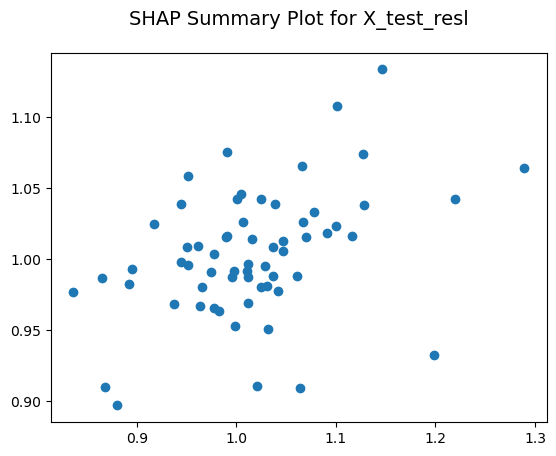

In [ ]:
# Plot y_test vs y_pred
plt.scatter(y_test_resl, y_pred_resl_test)



### Resistance

In [12]:
# Define objevtice function
def objective_cv_rest(space):
    model = xgb.XGBRegressor(
    objective='reg:squarederror',
    random_state=123,
    eta=space['eta'],
    gamma=space['gamma'],
    max_depth=int(space['max_depth']),
    min_child_weight=int(space['min_child_weight']),
    subsample=space['subsample'],
    colsample_bytree=space['colsample_bytree'],
    alpha=space['alpha']
)

    # Perform cross-validation
    cv_results = cross_val_score(model, X_train_rest, y_train_rest, cv=5, scoring='neg_mean_squared_error')

    # Compute the mean of the negative MSE scores
    mse = -cv_results.mean()

    return {'loss': mse, 'status': STATUS_OK}

# Store results
trials = Trials()

# Run optimization
best_hyperparams_rest = fmin(
    fn = objective_cv_rest,
    space=space,
    algo = tpe.suggest,
    max_evals = 1000,
    trials = trials,
    rstate = np.random.default_rng(123)
)


100%|██████████| 1000/1000 [05:46<00:00,  2.88trial/s, best loss: 0.06269665523273996]


In [13]:
# Initiate model with the best hyperparameters from Bayesian optimization
xgb_rest = xgb.XGBRegressor(
    eta = best_hyperparams_rest['eta'],
    gamma = best_hyperparams_rest['gamma'],
    max_depth = int(best_hyperparams_rest['max_depth']),
    min_child_weight = int(best_hyperparams_rest['min_child_weight']),
    subsample = best_hyperparams_rest['subsample'],
    colsample_bytree = best_hyperparams_rest['colsample_bytree'],
    alpha = best_hyperparams_rest['alpha']    
)


# Fit the model to the training data
xgb_rest.fit(X_train_rest, y_train_rest)

XGBRegressor(alpha=np.float64(0.07615258624840361), base_score=None,
             booster=None, callbacks=None, colsample_bylevel=None,
             colsample_bynode=None,
             colsample_bytree=np.float64(0.5360478178494742), device=None,
             early_stopping_rounds=None, enable_categorical=False,
             eta=np.float64(0.19972214560963825), eval_metric=None,
             feature_types=None, feature_weights=None,
             gamma=np.float64(0.009943682496926648), grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=None, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=4,
             max_leaves=None, min_child_weight=5, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=None, ...)

In [14]:
# Predict on training data
y_pred_rest_train = xgb_rest.predict(X_train_rest)

# Predict on test data
y_pred_rest_test = xgb_rest.predict(X_test_rest)

# Compute R² on both
r2_train = r2_score(y_train_rest, y_pred_rest_train)
r2_test = r2_score(y_test_rest, y_pred_rest_test)

print(r2_test)
print(r2_train)

0.9243428952328048
0.9951282993288453


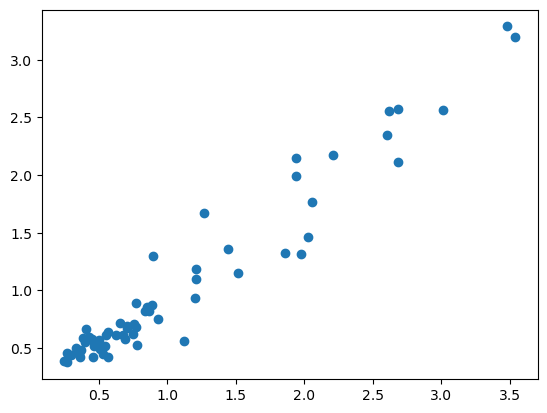

In [15]:
# Plot y_test vs y_pred

plt.scatter(y_test_rest, y_pred_rest_test)

### Recovery

In [16]:
# Define objevtice function
def objective_cv_rec(space):
    model = xgb.XGBRegressor(
    objective='reg:squarederror',
    random_state=123,
    eta=space['eta'],
    gamma=space['gamma'],
    max_depth=int(space['max_depth']),
    min_child_weight=int(space['min_child_weight']),
    subsample=space['subsample'],
    colsample_bytree=space['colsample_bytree'],
    alpha=space['alpha']
)

    # Perform cross-validation
    cv_results = cross_val_score(model, X_train_rec, y_train_rec, cv=5, scoring='neg_mean_squared_error')

    # Compute the mean of the negative MSE scores
    mse = -cv_results.mean()

    return {'loss': mse, 'status': STATUS_OK}

# Store results
trials = Trials()

# Run optimization
best_hyperparams_rec = fmin(
    fn = objective_cv_rest,
    space=space,
    algo = tpe.suggest,
    max_evals = 1000,
    trials = trials,
    rstate = np.random.default_rng(123)
)


100%|██████████| 1000/1000 [05:49<00:00,  2.86trial/s, best loss: 0.06269665523273996]


In [17]:
# Initiate model with the best hyperparameters from Bayesian optimization
xgb_rec = xgb.XGBRegressor(
    eta = best_hyperparams_rec['eta'],
    gamma = best_hyperparams_rec['gamma'],
    max_depth = int(best_hyperparams_rec['max_depth']),
    min_child_weight = int(best_hyperparams_rec['min_child_weight']),
    subsample = best_hyperparams_rec['subsample'],
    colsample_bytree = best_hyperparams_rec['colsample_bytree'],
    alpha = best_hyperparams_rec['alpha']    
)


# Fit the model to the training data
xgb_rec.fit(X_train_rec, y_train_rec)

XGBRegressor(alpha=np.float64(0.07615258624840361), base_score=None,
             booster=None, callbacks=None, colsample_bylevel=None,
             colsample_bynode=None,
             colsample_bytree=np.float64(0.5360478178494742), device=None,
             early_stopping_rounds=None, enable_categorical=False,
             eta=np.float64(0.19972214560963825), eval_metric=None,
             feature_types=None, feature_weights=None,
             gamma=np.float64(0.009943682496926648), grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=None, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=4,
             max_leaves=None, min_child_weight=5, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=None, ...)

In [18]:
# Predict on training data
y_pred_rec_train = xgb_rec.predict(X_train_rec)

# Predict on test data
y_pred_rec_test = xgb_rec.predict(X_test_rec)

# Compute R² on both
r2_train = r2_score(y_train_rec, y_pred_rec_train)
r2_test = r2_score(y_test_rec, y_pred_rec_test)

print(r2_test)
print(r2_train)

0.9053120767084457
0.9959213417932238


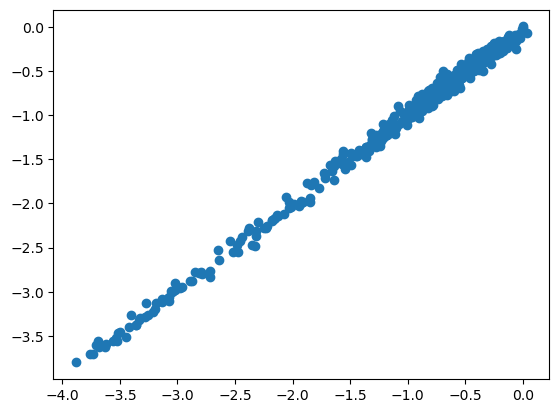

In [70]:
plt.scatter(y_train_rec, y_pred_rec_train)

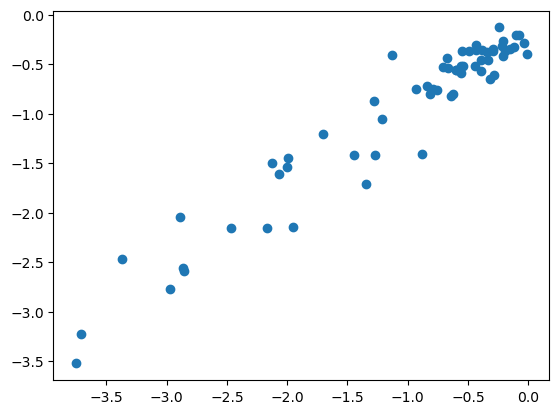

In [19]:
# Plot y_test vs y_pred

plt.scatter(y_test_rec, y_pred_rec_test)

#### kNDVI anomaly strength

In [24]:
# Define objevtice function
def objective_cv_anom(space):
    model = xgb.XGBRegressor(
    objective='reg:squarederror',
    random_state=123,
    eta=space['eta'],
    gamma=space['gamma'],
    max_depth=int(space['max_depth']),
    min_child_weight=int(space['min_child_weight']),
    subsample=space['subsample'],
    colsample_bytree=space['colsample_bytree'],
    alpha=space['alpha']
)

    # Perform cross-validation
    cv_results = cross_val_score(model, X_train_anom, y_train_anom, cv=5, scoring='neg_mean_squared_error')

    # Compute the mean of the negative MSE scores
    mse = -cv_results.mean()

    return {'loss': mse, 'status': STATUS_OK}

# Store results
trials = Trials()

# Run optimization
best_hyperparams_anom = fmin(
    fn = objective_cv_anom,
    space=space,
    algo = tpe.suggest,
    max_evals = 1000,
    trials = trials,
    rstate = np.random.default_rng(123)
)


  0%|          | 0/1000 [00:00<?, ?trial/s, best loss=?]

100%|██████████| 1000/1000 [05:08<00:00,  3.25trial/s, best loss: 0.03862702518337234]


In [21]:
# Initiate model with the best hyperparameters from Bayesian optimization
xgb_anom = xgb.XGBRegressor(
    eta = best_hyperparams_anom['eta'],
    gamma = best_hyperparams_anom['gamma'],
    max_depth = int(best_hyperparams_anom['max_depth']),
    min_child_weight = int(best_hyperparams_anom['min_child_weight']),
    subsample = best_hyperparams_anom['subsample'],
    colsample_bytree = best_hyperparams_anom['colsample_bytree'],
    alpha = best_hyperparams_anom['alpha']    
)


# Fit the model to the training data
xgb_anom.fit(X_train_anom, y_train_anom)

XGBRegressor(alpha=np.float64(0.07615258624840361), base_score=None,
             booster=None, callbacks=None, colsample_bylevel=None,
             colsample_bynode=None,
             colsample_bytree=np.float64(0.5360478178494742), device=None,
             early_stopping_rounds=None, enable_categorical=False,
             eta=np.float64(0.19972214560963825), eval_metric=None,
             feature_types=None, feature_weights=None,
             gamma=np.float64(0.009943682496926648), grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=None, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=4,
             max_leaves=None, min_child_weight=5, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=None, ...)

In [25]:
# Predict on training data
y_pred_anom_train = xgb_anom.predict(X_train_anom)

# Predict on the test set
y_pred_anom_test = xgb_anom.predict(X_test_anom)

# Compute R² on both
r2_train = r2_score(y_train_anom, y_pred_anom_train)
r2_test = r2_score(y_test_anom, y_pred_anom_test)

print(r2_test)
print(r2_train)

0.641560092946246
0.9333228721435922


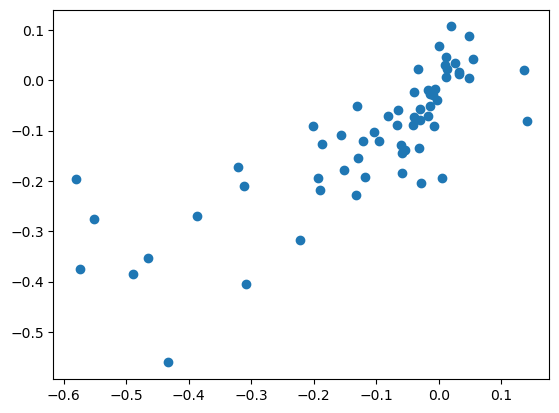

In [26]:
# Plot y_test vs y_pred

plt.scatter(y_test_anom, y_pred_anom_test)

### Feature importance
#### Resilience

In [30]:
explainer_resl = shap.Explainer(xgb_resl)
shap_values_resl = explainer_resl(X_test_resl)
shap.initjs() # Initializes havascript support

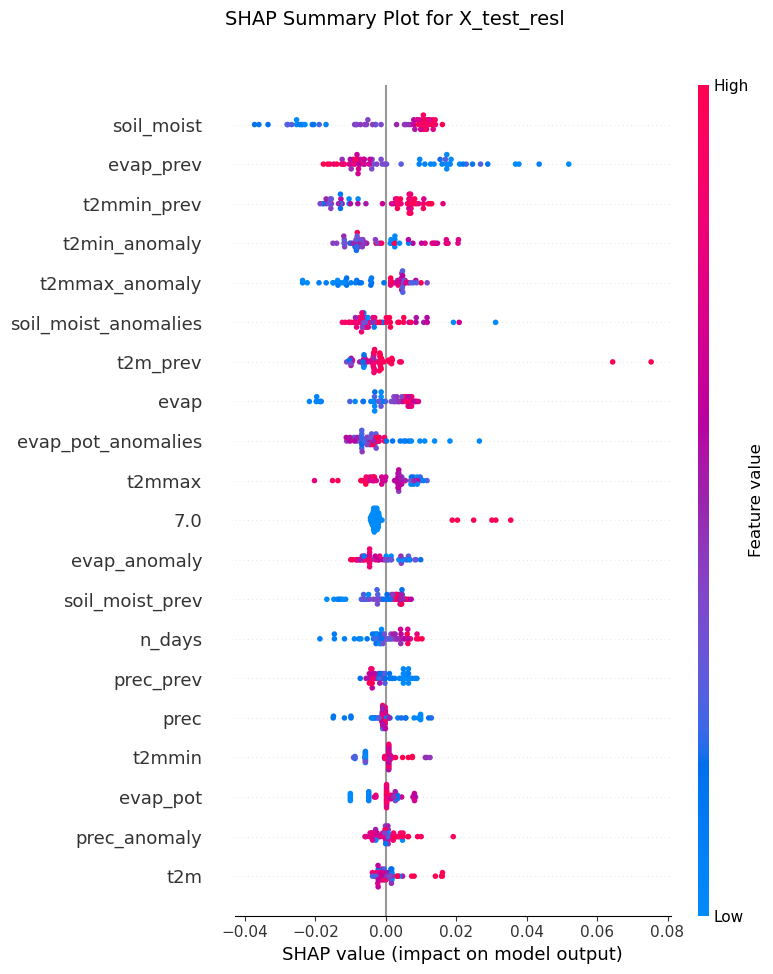

In [ ]:
plt.figure(figsize=(10, 6))
shap.summary_plot(shap_values_resl, X_test_resl, show=False)
plt.suptitle("SHAP Summary Plot for resilience mode", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

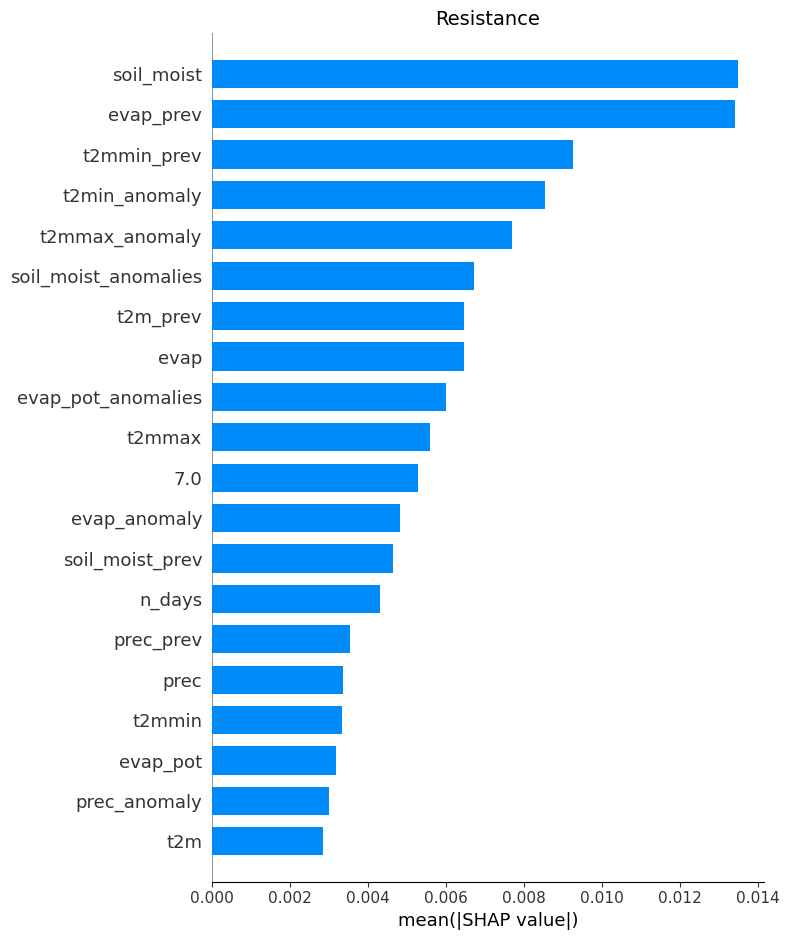

In [ ]:
shap.summary_plot(shap_values_resl, X_test_resl, plot_type="bar", show=False)

# Get current axis and add a title
plt.title("Resilience", fontsize=14)
plt.xlabel('mean(|SHAP value|)')

# Adjust layout and display
plt.tight_layout()
plt.show()

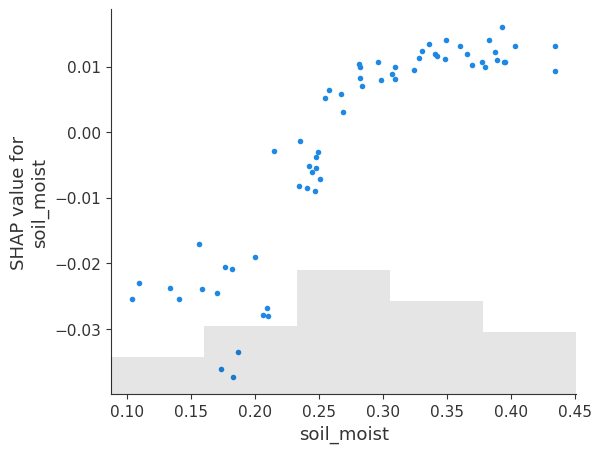

In [57]:
shap.plots.scatter(shap_values_resl[:, "soil_moist"])


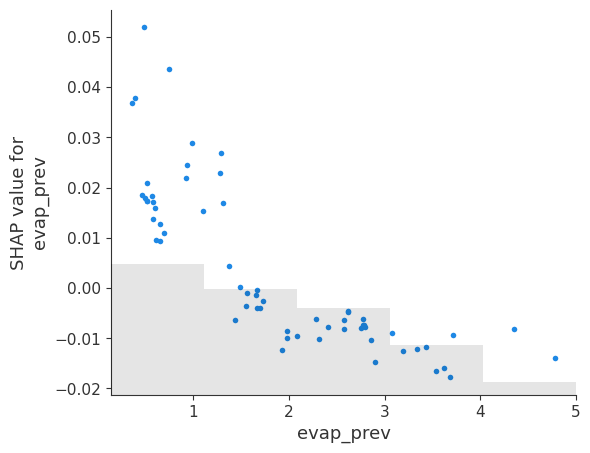

In [58]:
shap.plots.scatter(shap_values_resl[:, "evap_prev"])


#### Resistance

In [34]:
explainer_rest = shap.Explainer(xgb_rest)
shap_values_rest = explainer_rest(X_test_rest)

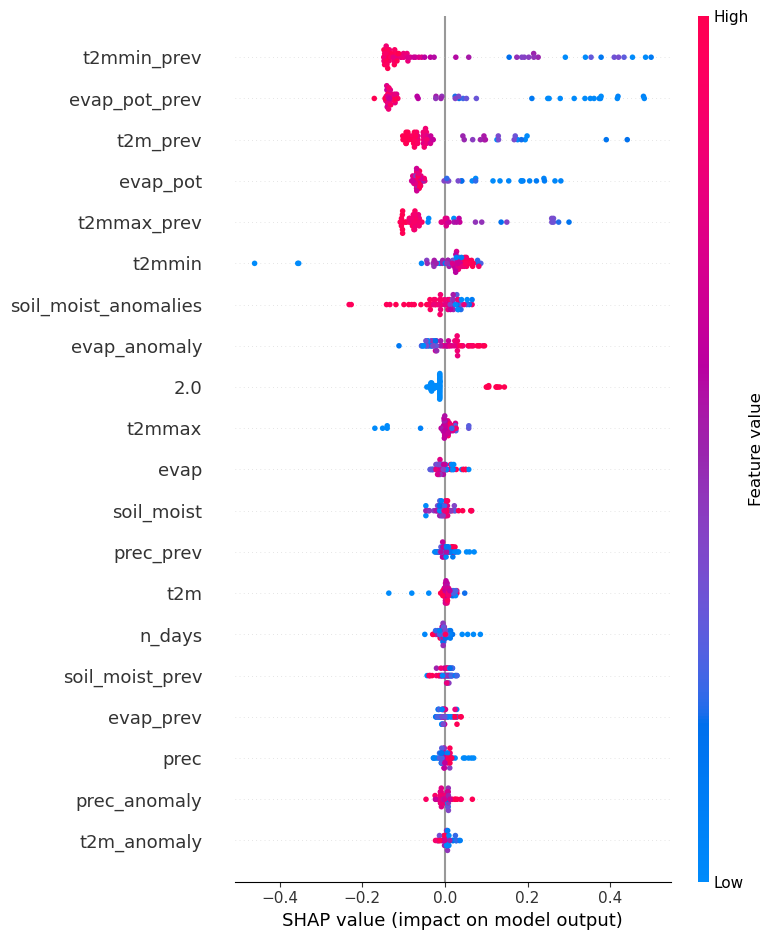

In [44]:
shap.summary_plot(shap_values_rest, X_test_rest)

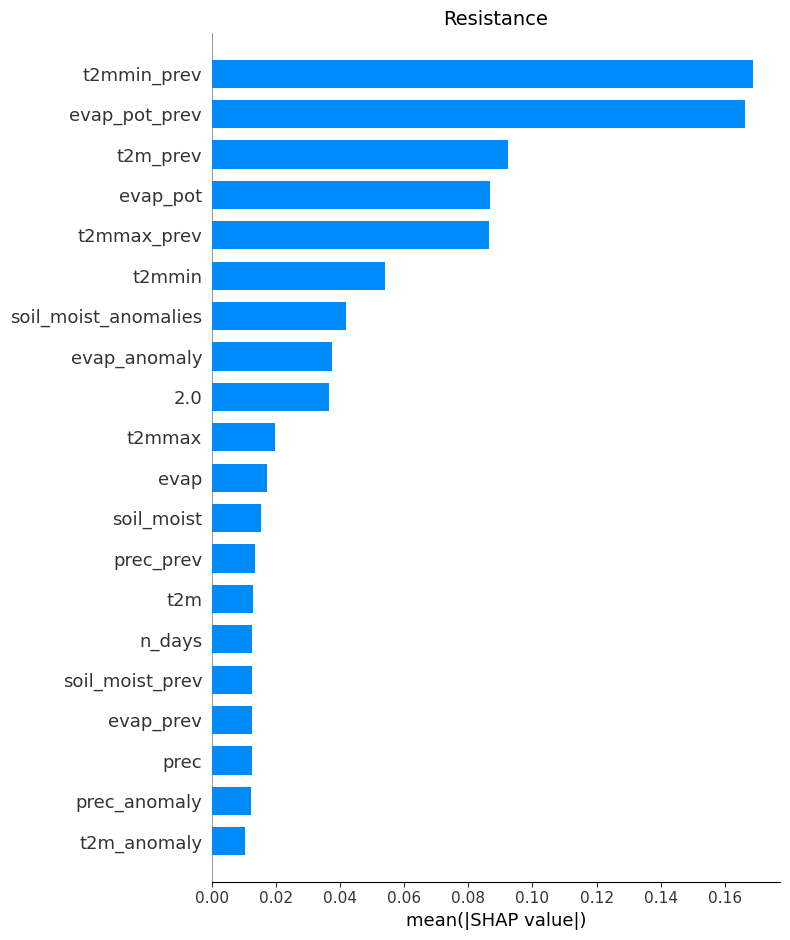

In [80]:
# Create SHAP summary plot
shap.summary_plot(shap_values_rest, X_test_rest, plot_type="bar", show=False)

# Get current axis and add a title
plt.title("Resistance", fontsize=14)
plt.xlabel('mean(|SHAP value|)')

# Adjust layout and display
plt.tight_layout()
plt.show()


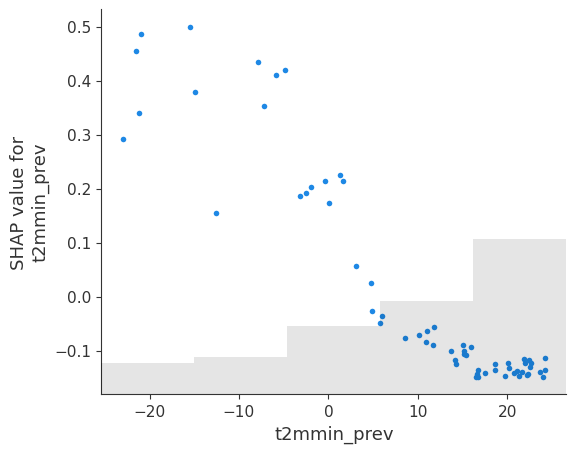

In [56]:
shap.plots.scatter(shap_values_rest[:, "t2mmin_prev"])


#### Recovery

In [37]:
explainer_rec = shap.Explainer(xgb_rec)
shap_values_rec = explainer_rec(X_test_rec)

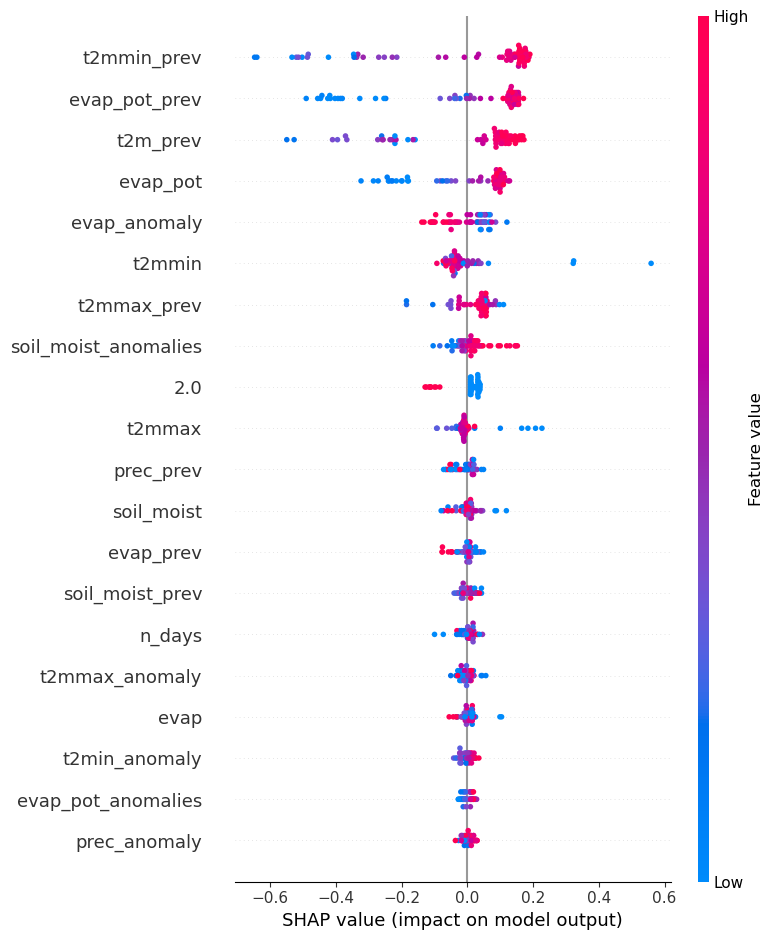

In [45]:
shap.summary_plot(shap_values_rec, X_test_rec)

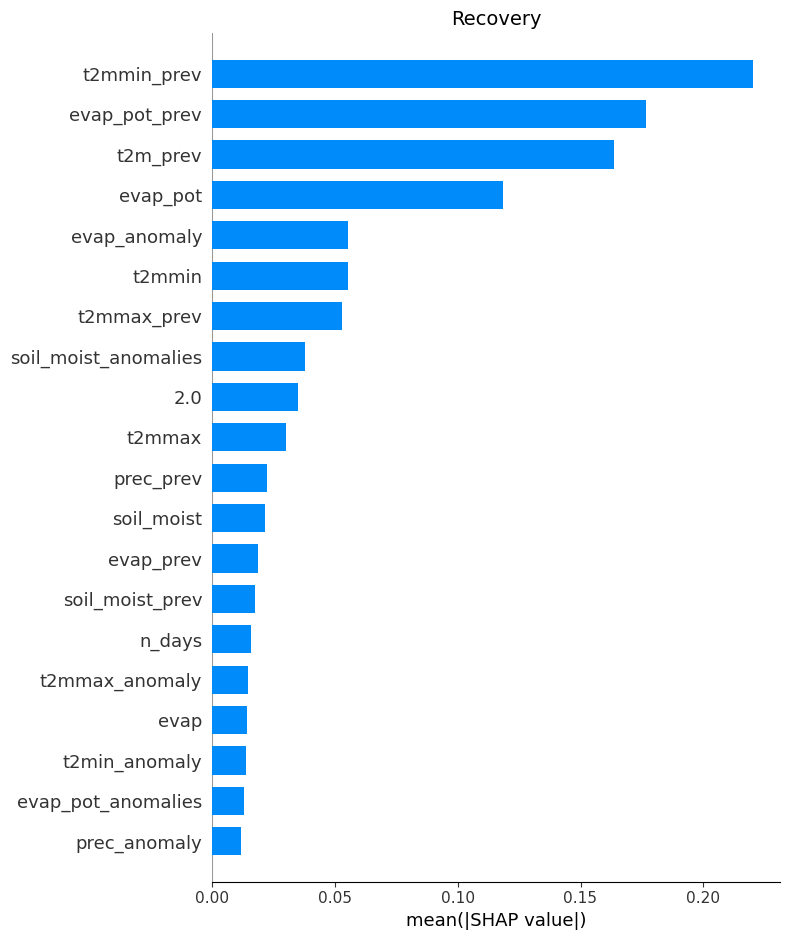

In [82]:
shap.summary_plot(shap_values_rec, X_test_rec, plot_type="bar", show=False)

# Get current axis and add a title
plt.title("Recovery", fontsize=14)
plt.xlabel('mean(|SHAP value|)')

# Adjust layout and display
plt.tight_layout()
plt.show()

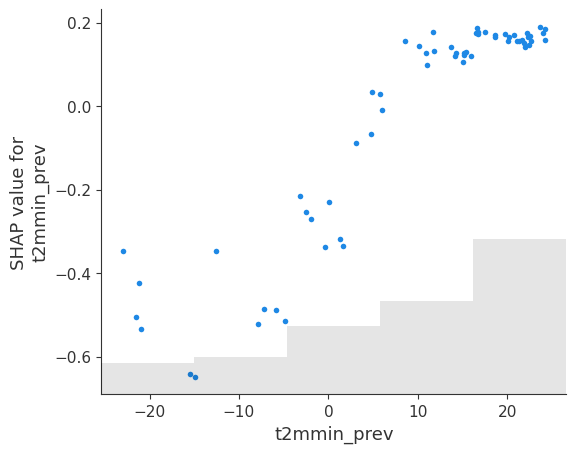

In [55]:
shap.plots.scatter(shap_values_rec[:, "t2mmin_prev"])


#### Anomaly

In [27]:
explainer_anom = shap.Explainer(xgb_anom)
shap_values_anom = explainer_anom(X_test_anom)

Global overview of feature impact per observation:

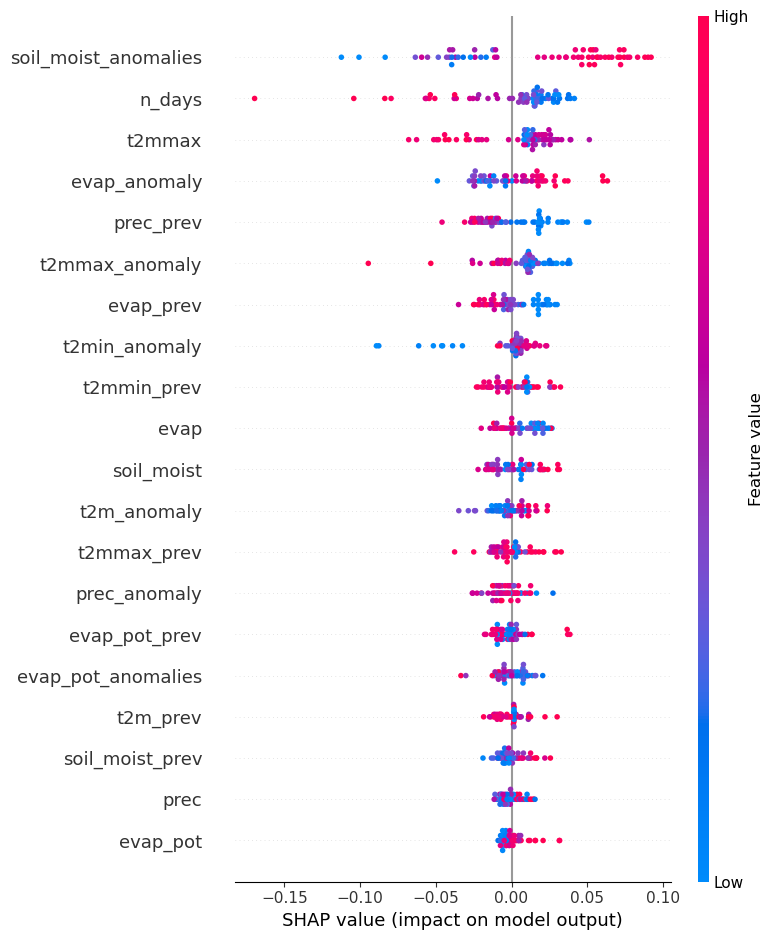

In [46]:
shap.summary_plot(shap_values_anom, X_test_anom)

Average feature impact across dataset:

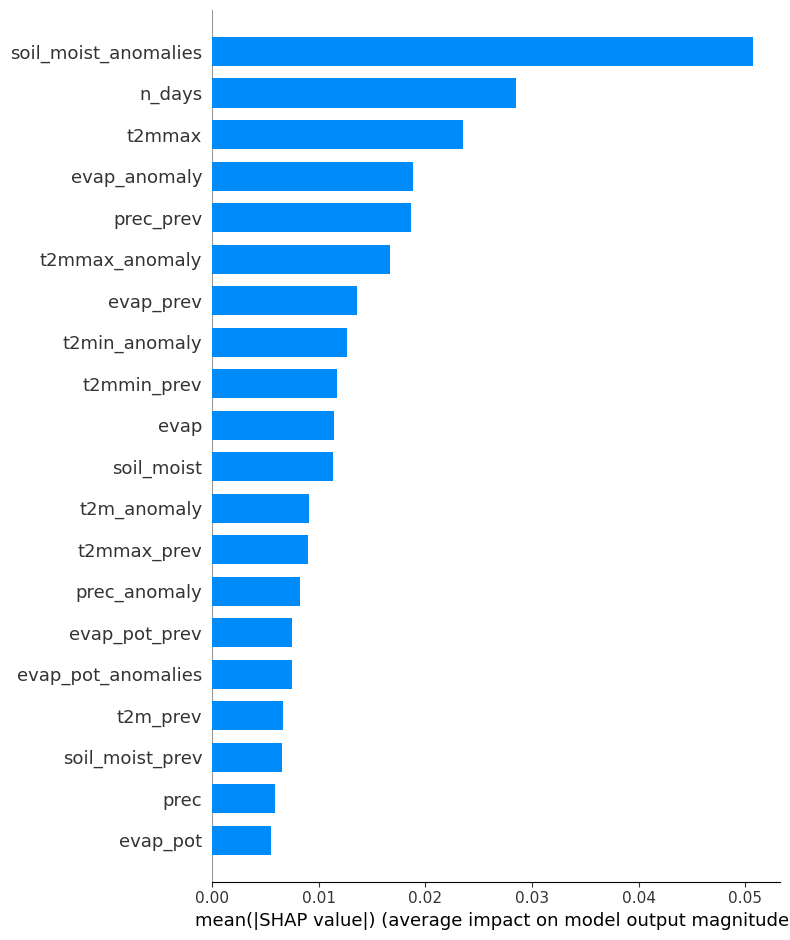

In [41]:
shap.summary_plot(shap_values_anom, X_test_anom, plot_type="bar")

Dependence plot of most important feature:

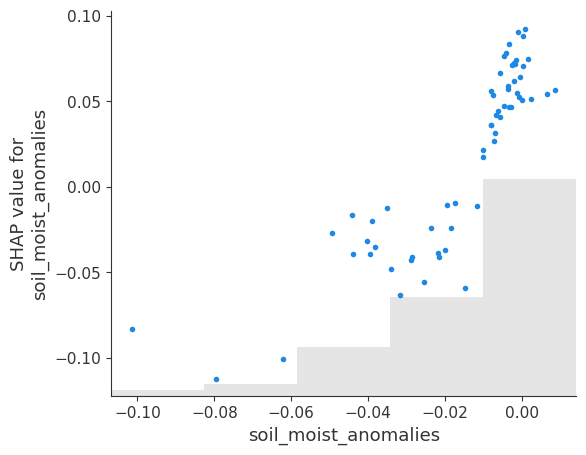

In [54]:
shap.plots.scatter(shap_values_anom[:, "soil_moist_anomalies"])


## SUmmary plots for document

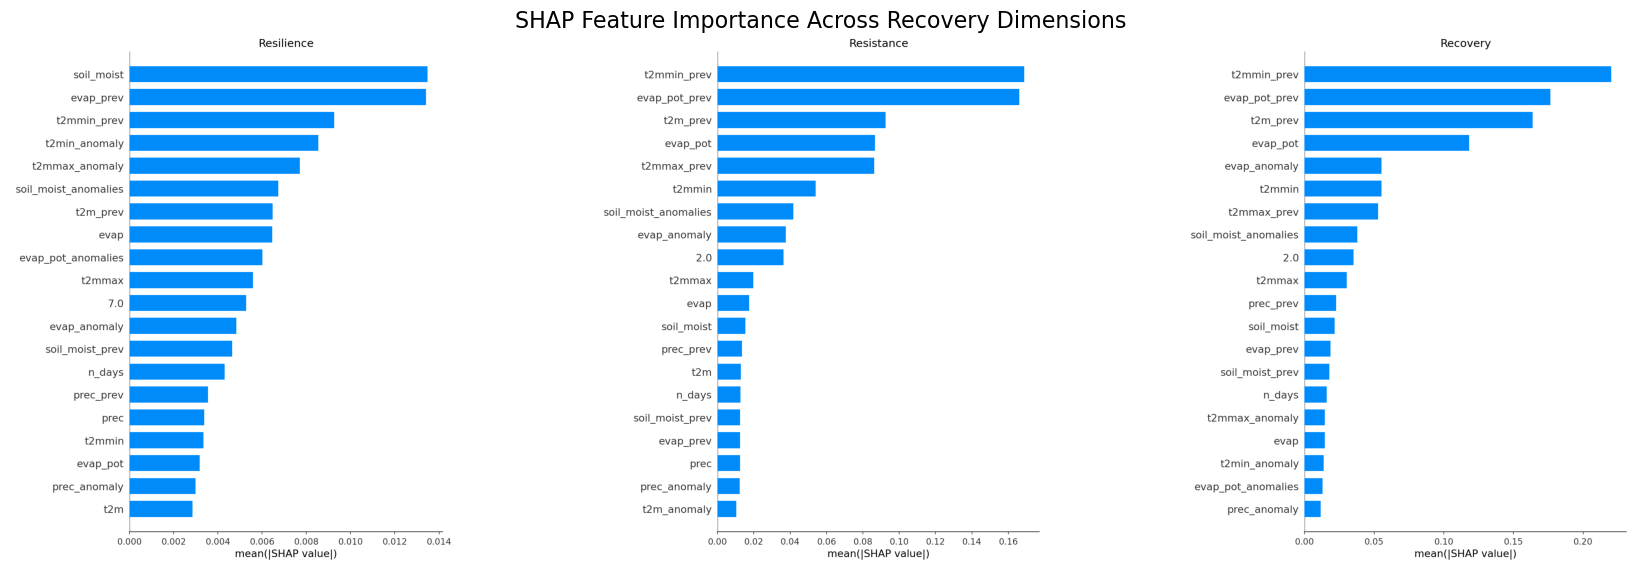

In [ ]:
# --- Generate each SHAP plot separately ---
shap.summary_plot(shap_values_resl, X_test_resl, plot_type="bar", show=False)
plt.title("Resilience", fontsize=14)
plt.xlabel("mean(|SHAP value|)")
plt.tight_layout()
plt.savefig("resilience_shap.png", bbox_inches="tight", dpi=150)
plt.close()

shap.summary_plot(shap_values_rest, X_test_rest, plot_type="bar", show=False)
plt.title("Resistance", fontsize=14)
plt.xlabel("mean(|SHAP value|)")
plt.tight_layout()
plt.savefig("resistance_shap.png", bbox_inches="tight", dpi=150)
plt.close()

shap.summary_plot(shap_values_rec, X_test_rec, plot_type="bar", show=False)
plt.title("Recovery", fontsize=14)
plt.xlabel("mean(|SHAP value|)")
plt.tight_layout()
plt.savefig("recovery_shap.png", bbox_inches="tight", dpi=150)
plt.close()

# --- Now combine them into one figure ---
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# Read the saved plots and show as images
imgs = ["resilience_shap.png", "resistance_shap.png", "recovery_shap.png"]
#titles = ["Resilience", "Resistance", "Recovery"]

for ax, img, title in zip(axes, imgs, titles):
    image = plt.imread(img)
    ax.imshow(image)
    ax.axis("off")
    #ax.set_title(title, fontsize=14)

plt.suptitle("Average Absolute Feature Importance (SHAP)", fontsize=16, y=0.95)
plt.tight_layout()
plt.show()


In [90]:
# Resilience
shap_resl_df = pd.DataFrame(np.abs(shap_values_resl.values), columns=X_test_resl.columns)

mean_shap_soil_moist_resl = shap_resl_df['soil_moist'].mean()
mean_shap_evap_prev_resl = shap_resl_df['evap_prev'].mean()

print('Resilience')
print(mean_shap_soil_moist_resl)
print(mean_shap_evap_prev_resl)
print('_______________________')

# Resistance
shap_rest_df = pd.DataFrame(np.abs(shap_values_rest.values), columns=X_test_rest.columns)

mean_shap_t2mmin_prev_rest = shap_rest_df['t2mmin_prev'].mean()
mean_shap_evap_pot_prev_rest = shap_rest_df['evap_pot_prev'].mean()

print('Resistance')
print(mean_shap_t2mmin_prev_rest)
print(mean_shap_evap_pot_prev_rest)
print('______________________')

# Recovery
shap_rec_df = pd.DataFrame(np.abs(shap_values_rec.values), columns=X_test_rec.columns)

mean_shap_t2mmin_prev_rec = shap_rec_df['t2mmin_prev'].mean()
mean_shap_evap_prev_rec = shap_rec_df['evap_pot_prev'].mean()

print('Recovery')
print(mean_shap_t2mmin_prev_rec)
print(mean_shap_evap_prev_rec)
print('_______________________')



Resilience
0.013480603
0.013416662
_______________________
Resistance
0.16875629
0.1661383
______________________
Recovery
0.22013853
0.1765652
_______________________


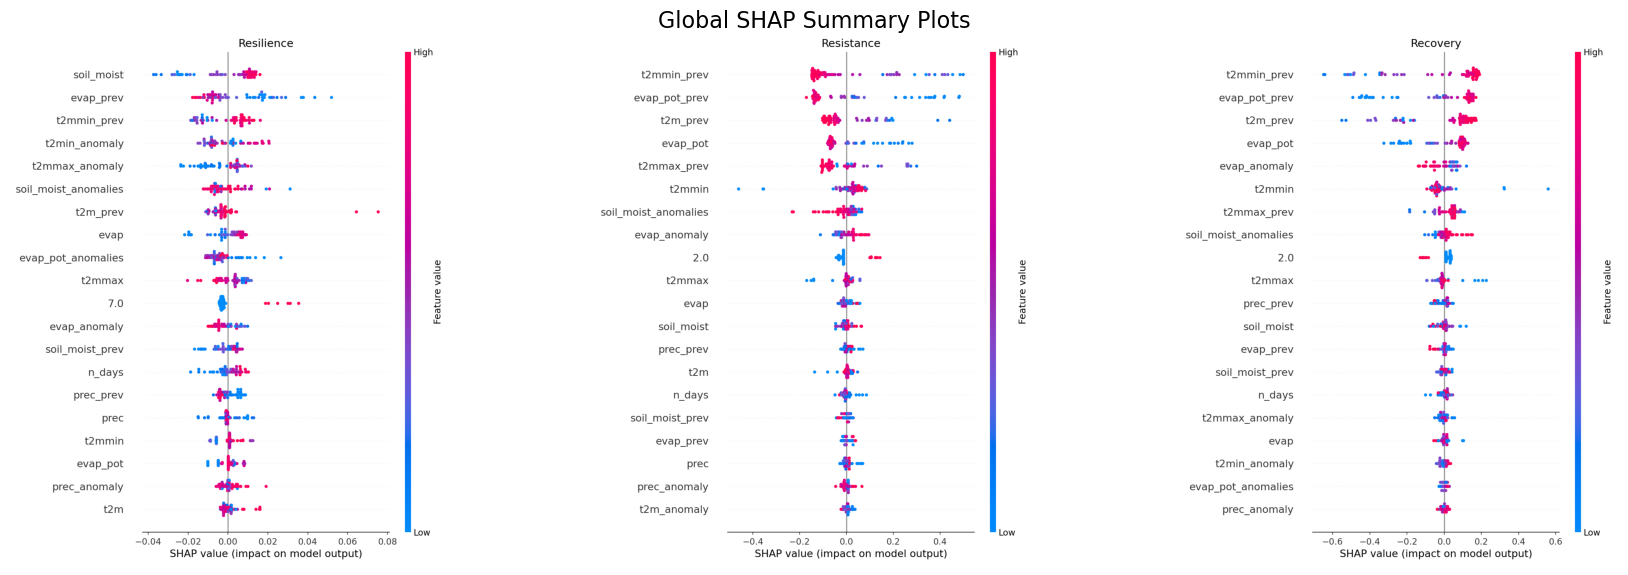

In [93]:
from io import BytesIO

# Helper to render a SHAP plot to an in-memory image
def shap_to_image(shap_values, X, title):
    buf = BytesIO()
    shap.summary_plot(shap_values, X, show=False)  # draw the plot
    plt.title(title, fontsize=14)
    plt.tight_layout()
    plt.savefig(buf, format="png", bbox_inches="tight", dpi=150)
    plt.close()
    buf.seek(0)
    return plt.imread(buf)

# Generate images in memory
img_resl = shap_to_image(shap_values_resl, X_test_resl, "Resilience")
img_rest = shap_to_image(shap_values_rest, X_test_rest, "Resistance")
img_rec  = shap_to_image(shap_values_rec,  X_test_rec,  "Recovery")

# Combine into one wide figure
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
for ax, img, title in zip(axes, [img_resl, img_rest, img_rec],
                          ["Resilience", "Resistance", "Recovery"]):
    ax.imshow(img)
    ax.axis("off")
    #ax.set_title(title, fontsize=14)

fig.suptitle("Global SHAP Summary Plots", fontsize=16, y=0.95)
plt.tight_layout()
plt.show()